C:\Users\Jair Neto\AppData\Local\Temp\ipykernel_13628\1454829768.py:183: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G2, pos5,


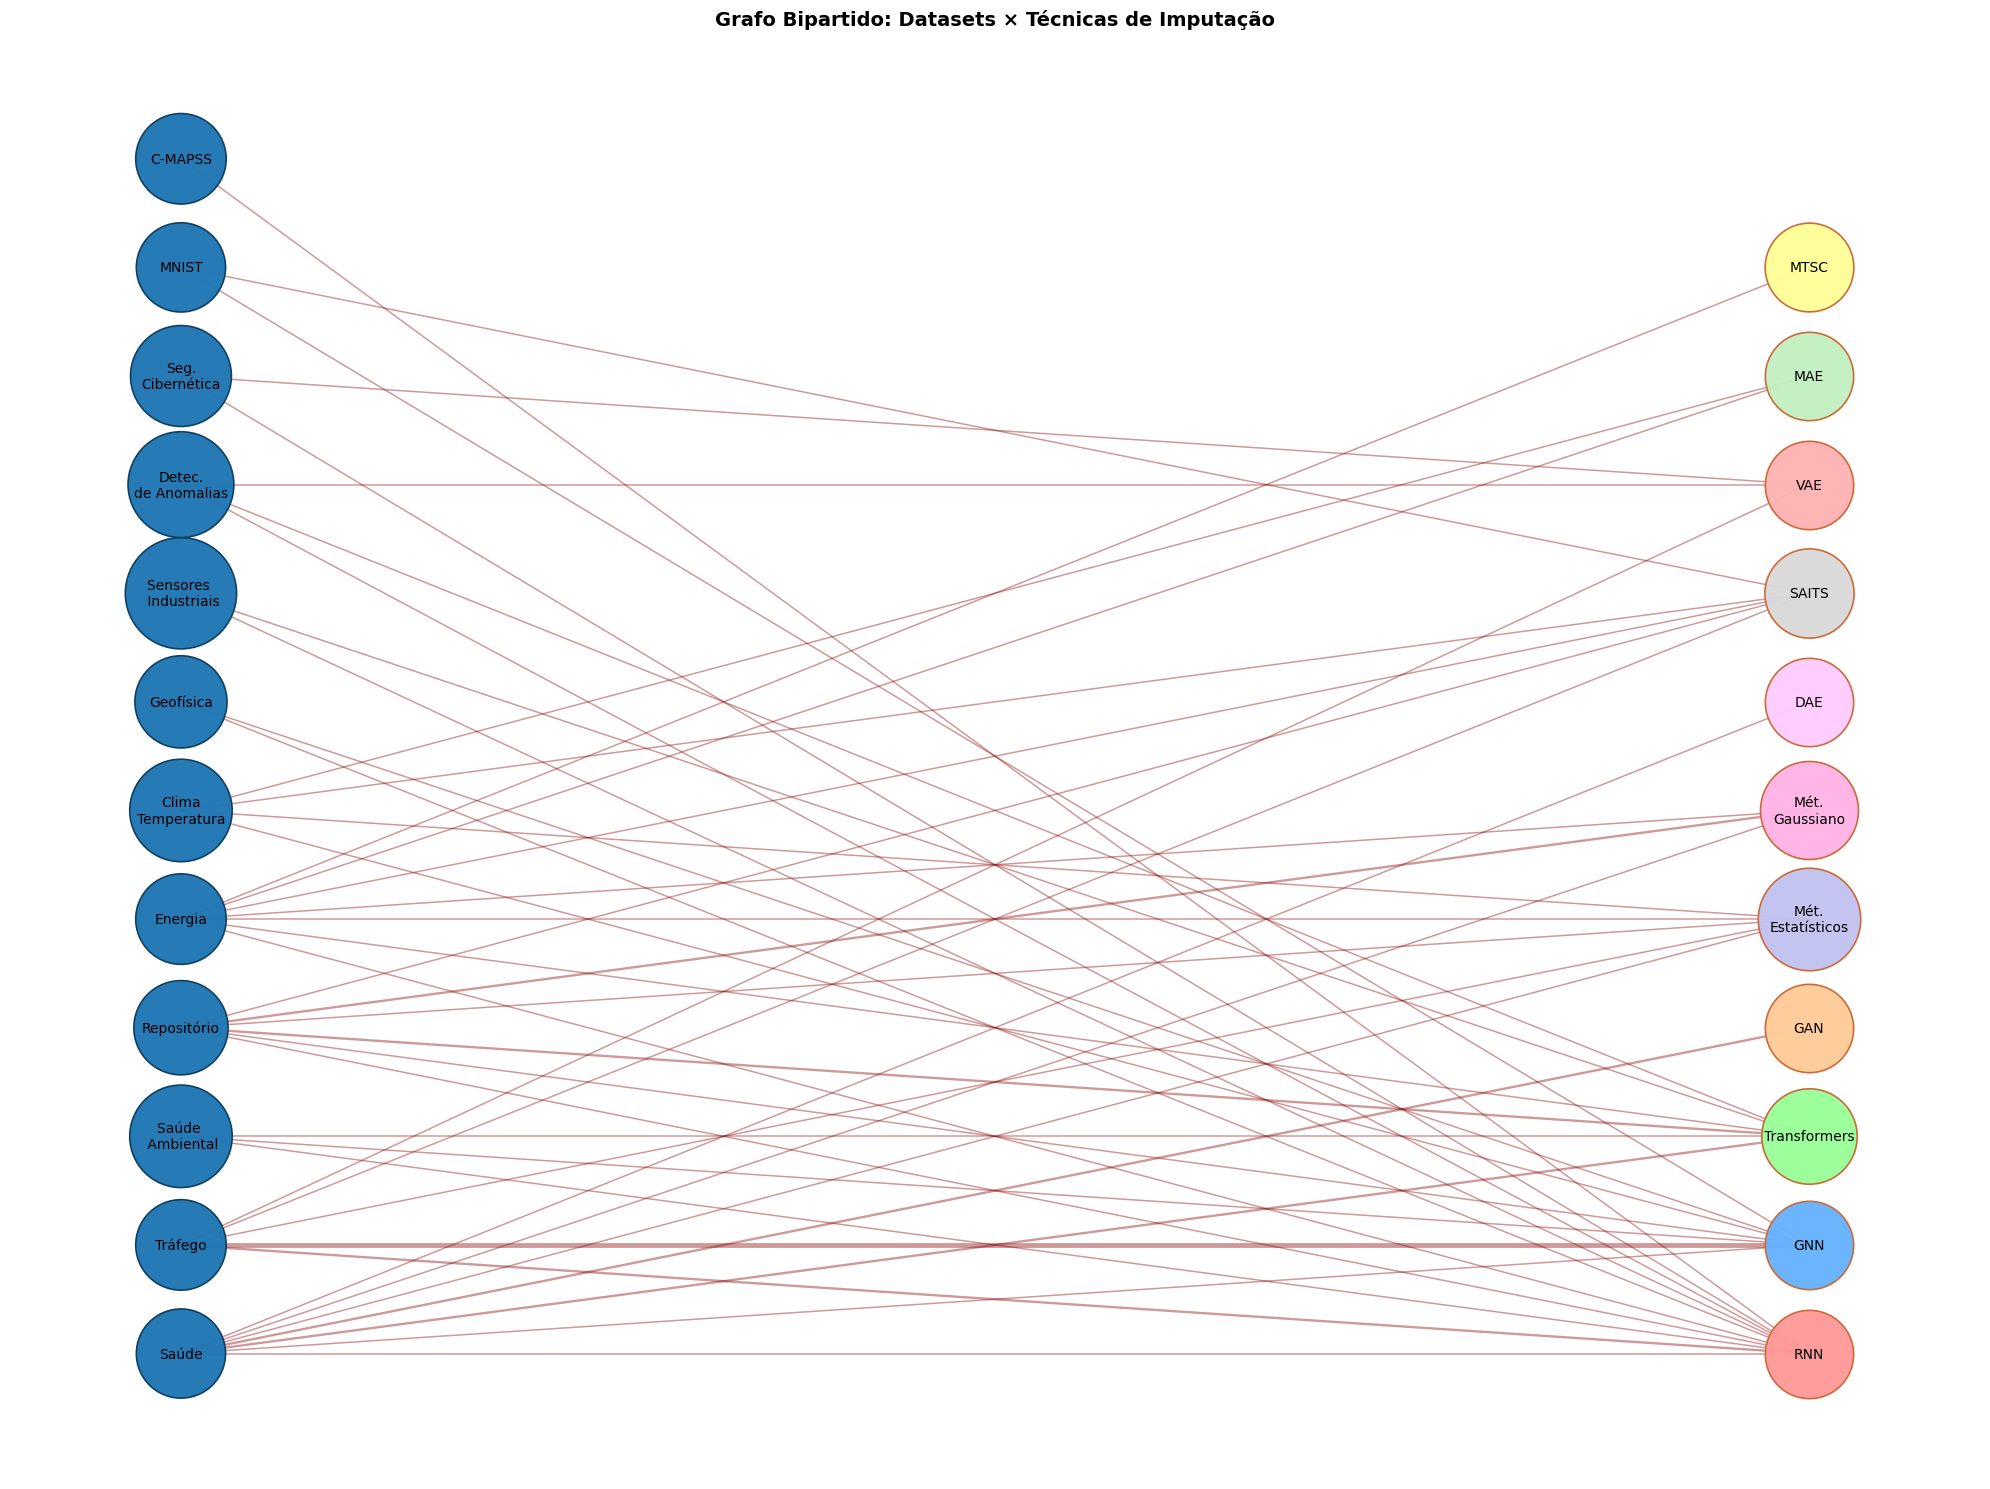

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ===== DEFINIÇÕES PARA O GRAFO DE DATASETS E TÉCNICAS DE IMPUTAÇÃO =====

# 1. Criar o grafo bipartido
G2 = nx.Graph()

# 2. Definir os datasets (lado esquerdo do grafo) - NOMES SIMPLIFICADOS
datasets = [
    'Saúde',
    'Tráfego',
    'Saúde \n Ambiental',  # Corrigido para utilização do "\n"
    'Repositório',
    'Energia',
    'Clima\nTemperatura',  # Corrigido para utilização do "\n"
    'Geofísica',
    'Sensores \n Industriais',  # Adicionada quebra de linha
    'Detec.\nde Anomalias',  # Adicionada quebra de linha
    'Seg.\nCibernética',  # Corrigido para utilização do "\n"
    'MNIST',
    'C-MAPSS'
]

# 3. Definir as técnicas de imputação (lado direito do grafo)
tecnicas = [
    'RNN',
    'GNN',
    'Transformers',
    'GAN',
    'Mét.\nEstatísticos',  # Adicionada quebra de linha
    'Mét.\nGaussiano',  # Corrigido para utilização do "\n"
    'DAE',
    'SAITS',
    'VAE',
    'MAE',
    'MTSC'
]

# 4. Adicionar os nós ao grafo
G2.add_nodes_from(datasets, bipartite=0)
G2.add_nodes_from(tecnicas, bipartite=1)

# 5. Adicionar arestas com pesos (conexões entre datasets e técnicas)
conexoes = [
    # Saúde
    ('Saúde', 'RNN', 1),
    ('Saúde', 'GNN', 1),
    ('Saúde', 'Transformers', 2),
    ('Saúde', 'GAN', 2),
    ('Saúde', 'Mét.\nEstatísticos', 1),
    ('Saúde', 'Mét.\nGaussiano', 1),
    ('Saúde', 'DAE', 1),
    
    # Tráfego
    ('Tráfego', 'RNN', 2),
    ('Tráfego', 'GNN', 5),
    ('Tráfego', 'SAITS', 1),
    ('Tráfego', 'Mét.\nEstatísticos', 1),
    ('Tráfego', 'VAE', 1),
    
    # Saúde Ambiental
    ('Saúde \n Ambiental', 'RNN', 1),
    ('Saúde \n Ambiental', 'GNN', 1),
    ('Saúde \n Ambiental', 'Transformers', 1),
    
    # Repositório
    ('Repositório', 'RNN', 1),
    ('Repositório', 'GNN', 1),
    ('Repositório', 'Transformers', 2),
    ('Repositório', 'SAITS', 1),
    ('Repositório', 'Mét.\nEstatísticos', 1),
    ('Repositório', 'Mét.\nGaussiano', 2),
    
    # Energia
    ('Energia', 'RNN', 1),
    ('Energia', 'Transformers', 1),
    ('Energia', 'SAITS', 1),
    ('Energia', 'Mét.\nEstatísticos', 1),
    ('Energia', 'Mét.\nGaussiano', 1),
    ('Energia', 'MAE', 1),
    ('Energia', 'MTSC', 1),
    
    # Clima/Temperatura
    ('Clima\nTemperatura', 'GNN', 1),
    ('Clima\nTemperatura', 'SAITS', 1),
    ('Clima\nTemperatura', 'Mét.\nEstatísticos', 1),
    ('Clima\nTemperatura', 'MAE', 1),
    
    # Geofísica
    ('Geofísica', 'RNN', 1),
    ('Geofísica', 'GNN', 1),
    
    # Sensores Industriais
    ('Sensores \n Industriais', 'RNN', 1),
    ('Sensores \n Industriais', 'Transformers', 1),
    
    # Detecção de Anomalias
    ('Detec.\nde Anomalias', 'RNN', 1),
    ('Detec.\nde Anomalias', 'Transformers', 1),
    ('Detec.\nde Anomalias', 'VAE', 1),
    
    # Segurança Cibernética
    ('Seg.\nCibernética', 'RNN', 1),
    ('Seg.\nCibernética', 'VAE', 1),
    
    # MNIST
    ('MNIST', 'GNN', 1),
    ('MNIST', 'SAITS', 1),
    
    # C-MAPSS
    ('C-MAPSS', 'RNN', 1),
]

for dataset, tecnica, peso in conexoes:
    G2.add_edge(dataset, tecnica, weight=peso)

# 6. Definir a ordem dos nós
cat_order = datasets
tec_order = tecnicas

# ===== CÓDIGO DE VISUALIZAÇÃO =====

# Função para ajustar o tamanho dos nós
def adjusted_node_size(label_txt):
    base_size5 = 4000
    size_scale5 = 5  # Pequeno ajuste para controlar tamanhos
    ln = len(label_txt)
    size_val = base_size5 + size_scale5 * (ln ** 2)
    return float(size_val)

cat_sizes5 = [adjusted_node_size(n) for n in cat_order]
tec_sizes5 = [adjusted_node_size(n) for n in tec_order]

# Cores para as técnicas
cores_tecnicas = {
    'RNN': '#ff9999',
    'GNN': '#66b3ff',
    'Transformers': '#99ff99',
    'GAN': '#ffcc99',
    'Mét.\nEstatísticos': '#c2c2f0',
    'Mét.\nGaussiano': '#ffb3e6',
    'DAE': '#ffccff',
    'SAITS': '#d9d9d9',
    'VAE': '#ffb3b3',
    'MAE': '#c2f0c2',
    'MTSC': '#ffff99'
}

# Definindo posições
pos5 = {}
for i, n in enumerate(cat_order):
    pos5[n] = (0, i * 2)
for j, n in enumerate(tec_order):
    pos5[n] = (1, j * 2)

# Estilo das arestas
weights5 = [G2[u][v]['weight'] for u, v in G2.edges()]
max_w5 = max(weights5) if len(weights5) else 1
edge_widths5 = [0.5 + 3.0 * (w / max_w5) for w in weights5]

plt.figure(figsize=(20, 15))

# Datasets em azul
nx.draw_networkx_nodes(G2, pos5, nodelist=cat_order, 
                       node_color='#1f77b4', 
                       node_size=cat_sizes5, 
                       alpha=0.97, 
                       linewidths=1.2, 
                       edgecolors='#0d3d5c')

# Técnicas
for técnica in tec_order:
    nx.draw_networkx_nodes(G2, pos5, nodelist=[técnica], 
                           node_color=cores_tecnicas[técnica], 
                           node_size=tec_sizes5[tec_order.index(técnica)], 
                           alpha=0.97, 
                           linewidths=1.2, 
                           edgecolors='#cc6633')

# Linhas em vermelho
nx.draw_networkx_edges(G2, pos5, 
                       width=edge_widths5, 
                       edge_color='#8B0000', 
                       alpha=0.40, 
                       connectionstyle='arc3,rad=0.15')

# Ajustando as labels com quebras de linha
wrapped_labels = {}
for n in G2.nodes():
    wrapped_labels[n] = n.replace('\\n', '\n')

nx.draw_networkx_labels(G2, pos5, labels=wrapped_labels, font_size=10, font_color='black')

plt.title('Grafo Bipartido: Datasets × Técnicas de Imputação', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

C:\Users\Jair Neto\AppData\Local\Temp\ipykernel_13628\208972468.py:205: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G2, pos5,


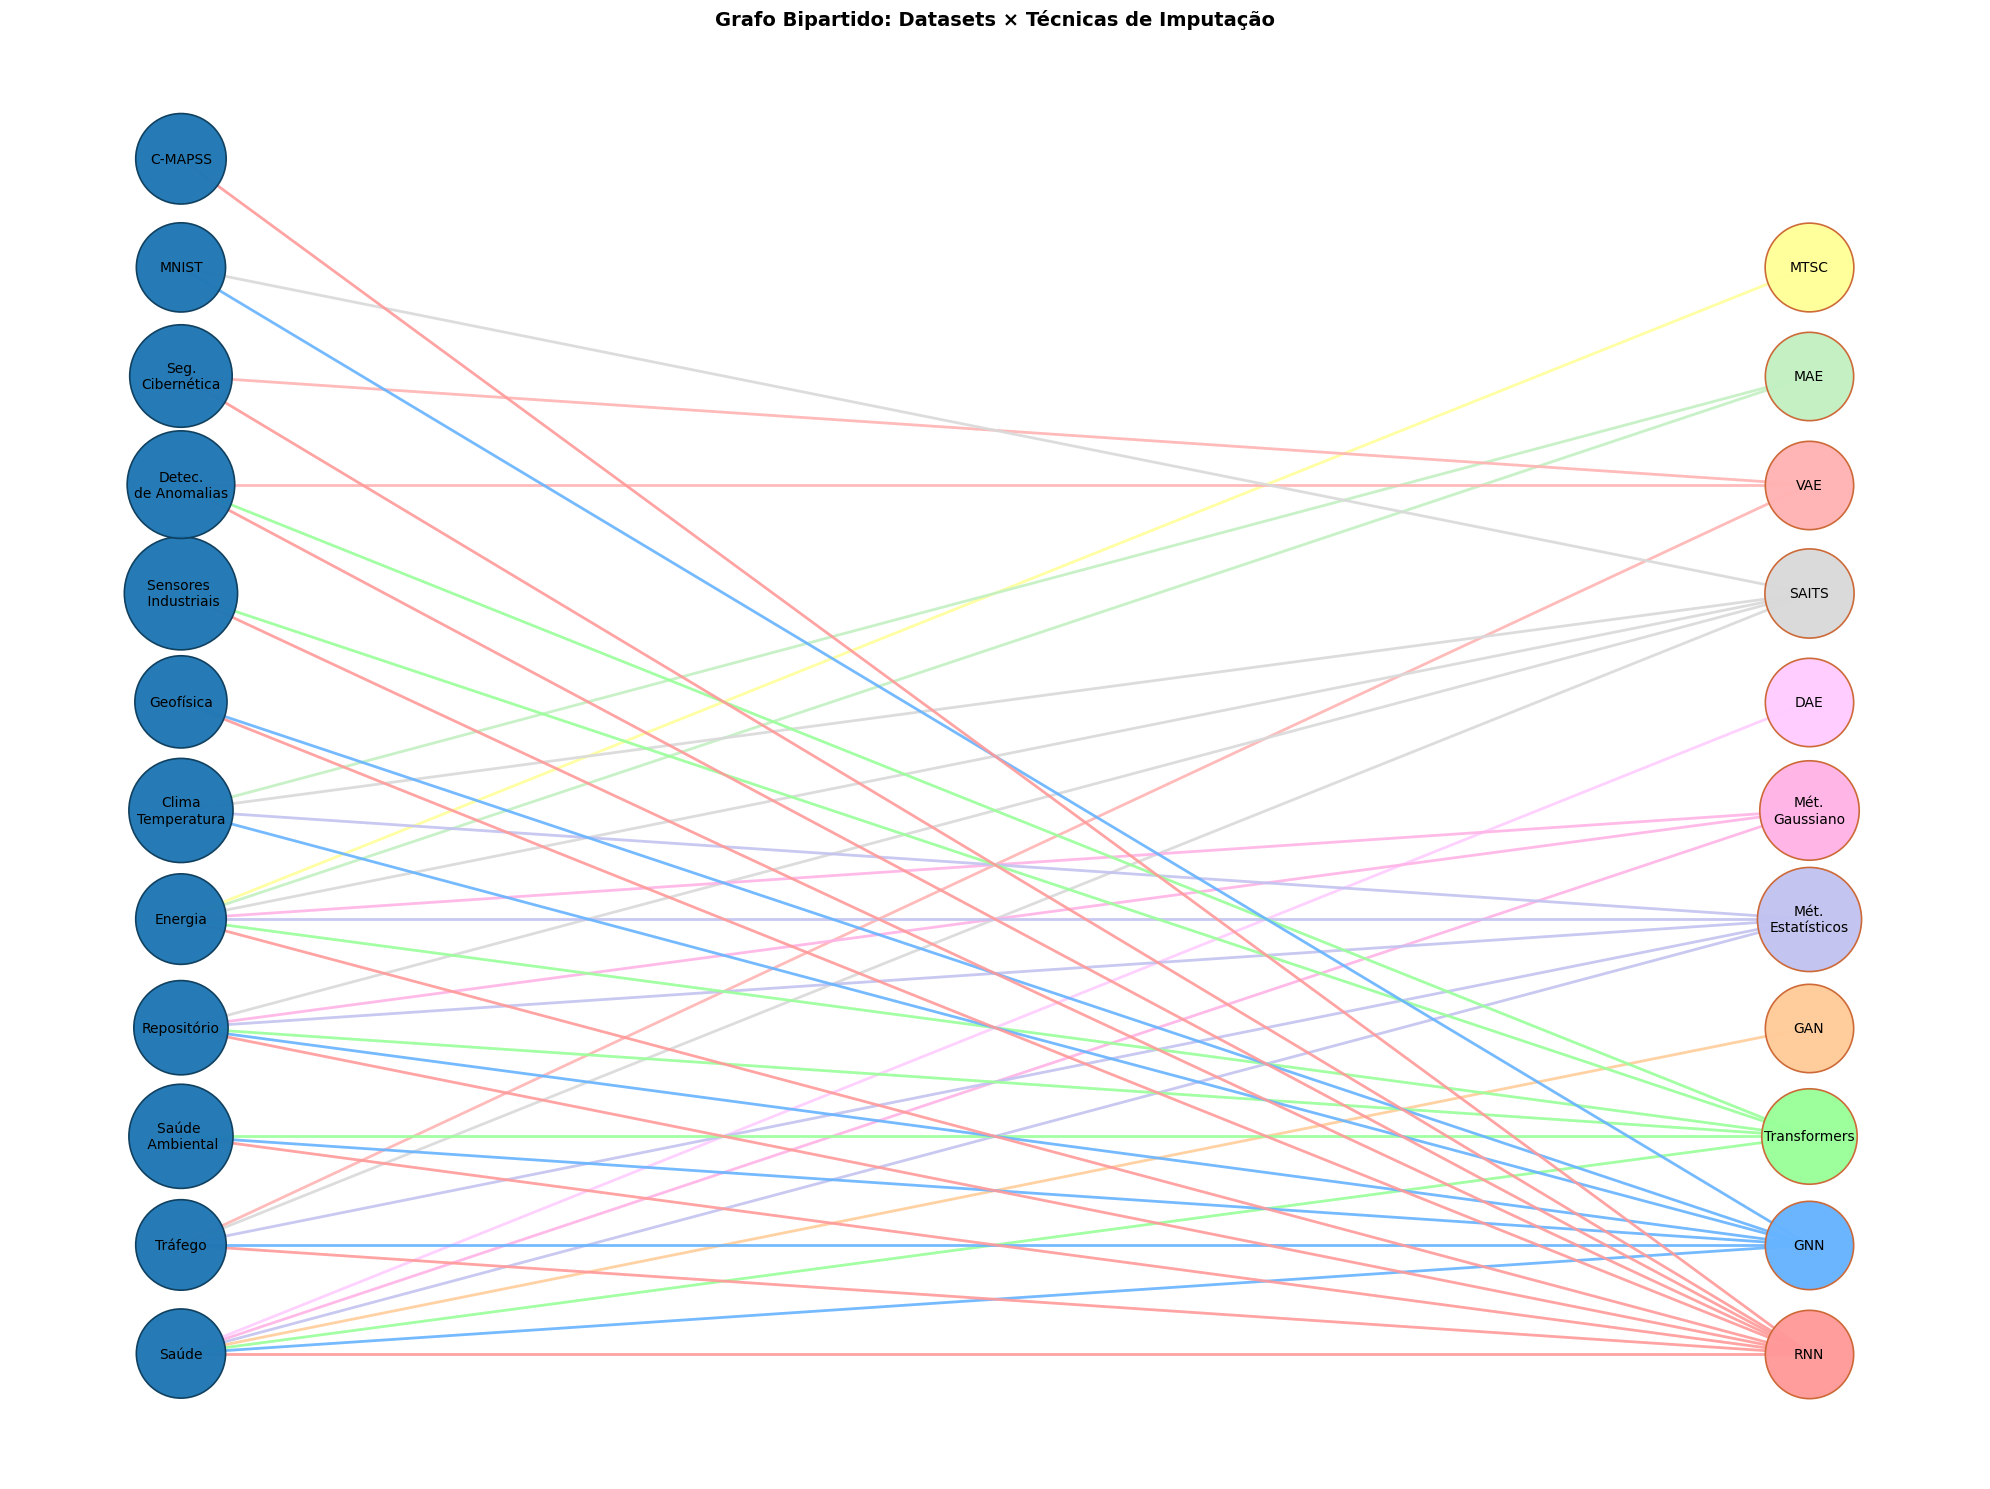

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ===== DEFINIÇÕES PARA O GRAFO DE DATASETS E TÉCNICAS DE IMPUTAÇÃO =====

# 1. Criar o grafo bipartido
G2 = nx.Graph()

# 2. Definir os datasets (lado esquerdo do grafo) - NOMES SIMPLIFICADOS
datasets = [
    'Saúde',
    'Tráfego',
    'Saúde \\n Ambiental',
    'Repositório',
    'Energia',
    'Clima\\nTemperatura',
    'Geofísica',
    'Sensores \\n Industriais',
    'Detec.\\nde Anomalias',
    'Seg.\\nCibernética',
    'MNIST',
    'C-MAPSS'
]

# 3. Definir as técnicas de imputação (lado direito do grafo)
tecnicas = [
    'RNN',
    'GNN',
    'Transformers',
    'GAN',
    'Mét.\\nEstatísticos',
    'Mét.\\nGaussiano',
    'DAE',
    'SAITS',
    'VAE',
    'MAE',
    'MTSC'
]

# 4. Adicionar os nós ao grafo
G2.add_nodes_from(datasets, bipartite=0)
G2.add_nodes_from(tecnicas, bipartite=1)

# 5. Adicionar arestas com pesos (conexões entre datasets e técnicas)
conexoes = [
    # Saúde
    ('Saúde', 'RNN', 1),
    ('Saúde', 'GNN', 1),
    ('Saúde', 'Transformers', 2),
    ('Saúde', 'GAN', 2),
    ('Saúde', 'Mét.\\nEstatísticos', 1),
    ('Saúde', 'Mét.\\nGaussiano', 1),
    ('Saúde', 'DAE', 1),
    
    # Tráfego
    ('Tráfego', 'RNN', 2),
    ('Tráfego', 'GNN', 5),
    ('Tráfego', 'SAITS', 1),
    ('Tráfego', 'Mét.\\nEstatísticos', 1),
    ('Tráfego', 'VAE', 1),
    
    # Saúde Ambiental
    ('Saúde \\n Ambiental', 'RNN', 1),
    ('Saúde \\n Ambiental', 'GNN', 1),
    ('Saúde \\n Ambiental', 'Transformers', 1),
    
    # Repositório
    ('Repositório', 'RNN', 1),
    ('Repositório', 'GNN', 1),
    ('Repositório', 'Transformers', 2),
    ('Repositório', 'SAITS', 1),
    ('Repositório', 'Mét.\\nEstatísticos', 1),
    ('Repositório', 'Mét.\\nGaussiano', 2),
    
    # Energia
    ('Energia', 'RNN', 1),
    ('Energia', 'Transformers', 1),
    ('Energia', 'SAITS', 1),
    ('Energia', 'Mét.\\nEstatísticos', 1),
    ('Energia', 'Mét.\\nGaussiano', 1),
    ('Energia', 'MAE', 1),
    ('Energia', 'MTSC', 1),
    
    # Clima/Temperatura
    ('Clima\\nTemperatura', 'GNN', 1),
    ('Clima\\nTemperatura', 'SAITS', 1),
    ('Clima\\nTemperatura', 'Mét.\\nEstatísticos', 1),
    ('Clima\\nTemperatura', 'MAE', 1),
    
    # Geofísica
    ('Geofísica', 'RNN', 1),
    ('Geofísica', 'GNN', 1),
    
    # Sensores Industriais
    ('Sensores \\n Industriais', 'RNN', 1),
    ('Sensores \\n Industriais', 'Transformers', 1),
    
    # Detecção de Anomalias
    ('Detec.\\nde Anomalias', 'RNN', 1),
    ('Detec.\\nde Anomalias', 'Transformers', 1),
    ('Detec.\\nde Anomalias', 'VAE', 1),
    
    # Segurança Cibernética
    ('Seg.\\nCibernética', 'RNN', 1),
    ('Seg.\\nCibernética', 'VAE', 1),
    
    # MNIST
    ('MNIST', 'GNN', 1),
    ('MNIST', 'SAITS', 1),
    
    # C-MAPSS
    ('C-MAPSS', 'RNN', 1),
]

for dataset, tecnica, peso in conexoes:
    G2.add_edge(dataset, tecnica, weight=peso)

# 6. Definir a ordem dos nós
cat_order = datasets
tec_order = tecnicas

# ===== CÓDIGO DE VISUALIZAÇÃO =====

# Função para ajustar o tamanho dos nós
def adjusted_node_size(label_txt):
    base_size5 = 4000
    size_scale5 = 5  # Pequeno ajuste para controlar tamanhos
    ln = len(label_txt)
    size_val = base_size5 + size_scale5 * (ln ** 2)
    return float(size_val)

cat_sizes5 = [adjusted_node_size(n) for n in cat_order]
tec_sizes5 = [adjusted_node_size(n) for n in tec_order]

# Cores para as técnicas
cores_tecnicas = {
    'RNN': '#ff9999',
    'GNN': '#66b3ff',
    'Transformers': '#99ff99',
    'GAN': '#ffcc99',
    'Mét.\\nEstatísticos': '#c2c2f0',
    'Mét.\\nGaussiano': '#ffb3e6',
    'DAE': '#ffccff',
    'SAITS': '#d9d9d9',
    'VAE': '#ffb3b3',
    'MAE': '#c2f0c2',
    'MTSC': '#ffff99'
}

# Definindo posições
pos5 = {}
for i, n in enumerate(cat_order):
    pos5[n] = (0, i * 2)
for j, n in enumerate(tec_order):
    pos5[n] = (1, j * 2)

# Estilo das arestas com cores variáveis
edges_colors = []
for u, v in G2.edges():
    if v == 'GNN':
        edges_colors.append('#66b3ff')  # Azul para GNN
    elif v == 'MTSC':
        edges_colors.append('#ffff99')  # Amarelo para MTSC
    elif v == 'RNN':
        edges_colors.append('#ff9999')  # Vermelho para RNN
    elif v == 'Transformers':
        edges_colors.append('#99ff99')  # Verde para Transformers
    elif v == 'GAN':
        edges_colors.append('#ffcc99')  # Laranja para GAN
    elif v == 'Mét.\\nEstatísticos':
        edges_colors.append('#c2c2f0')  # Roxo claro para Mét. Estatísticos
    elif v == 'Mét.\\nGaussiano':
        edges_colors.append('#ffb3e6')  # Rosa claro para Método Gaussiano
    elif v == 'DAE':
        edges_colors.append('#ffccff')  # Lilás para DAE
    elif v == 'SAITS':
        edges_colors.append('#d9d9d9')  # Cinza para SAITS
    elif v == 'VAE':
        edges_colors.append('#ffb3b3')  # Vermelho suave para VAE
    elif v == 'MAE':
        edges_colors.append('#c2f0c2')  # Verde suave para MAE

# Criar a visualização
plt.figure(figsize=(20, 15))

# Datasets em azul
nx.draw_networkx_nodes(G2, pos5, nodelist=cat_order, 
                       node_color='#1f77b4', 
                       node_size=cat_sizes5, 
                       alpha=0.97, 
                       linewidths=1.2, 
                       edgecolors='#0d3d5c')

# Técnicas
for técnica in tec_order:
    nx.draw_networkx_nodes(G2, pos5, nodelist=[técnica], 
                           node_color=cores_tecnicas[técnica], 
                           node_size=tec_sizes5[tec_order.index(técnica)], 
                           alpha=0.97, 
                           linewidths=1.2, 
                           edgecolors='#cc6633')

# Linhas com cores customizadas - aumentando a intensidade
nx.draw_networkx_edges(G2, pos5, 
                       width=2, 
                       edge_color=edges_colors,  # Cores variáveis para cada aresta
                       alpha=0.90,  # Aumentando a opacidade
                       connectionstyle='arc3,rad=0.15')

# Ajustando as labels com quebras de linha
wrapped_labels = {}
for n in G2.nodes():
    wrapped_labels[n] = n.replace('\\n', '\n')

nx.draw_networkx_labels(G2, pos5, labels=wrapped_labels, font_size=10, font_color='black')

plt.title('Grafo Bipartido: Datasets × Técnicas de Imputação', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


C:\Users\Jair Neto\AppData\Local\Temp\ipykernel_13628\217280772.py:209: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G2, pos5,


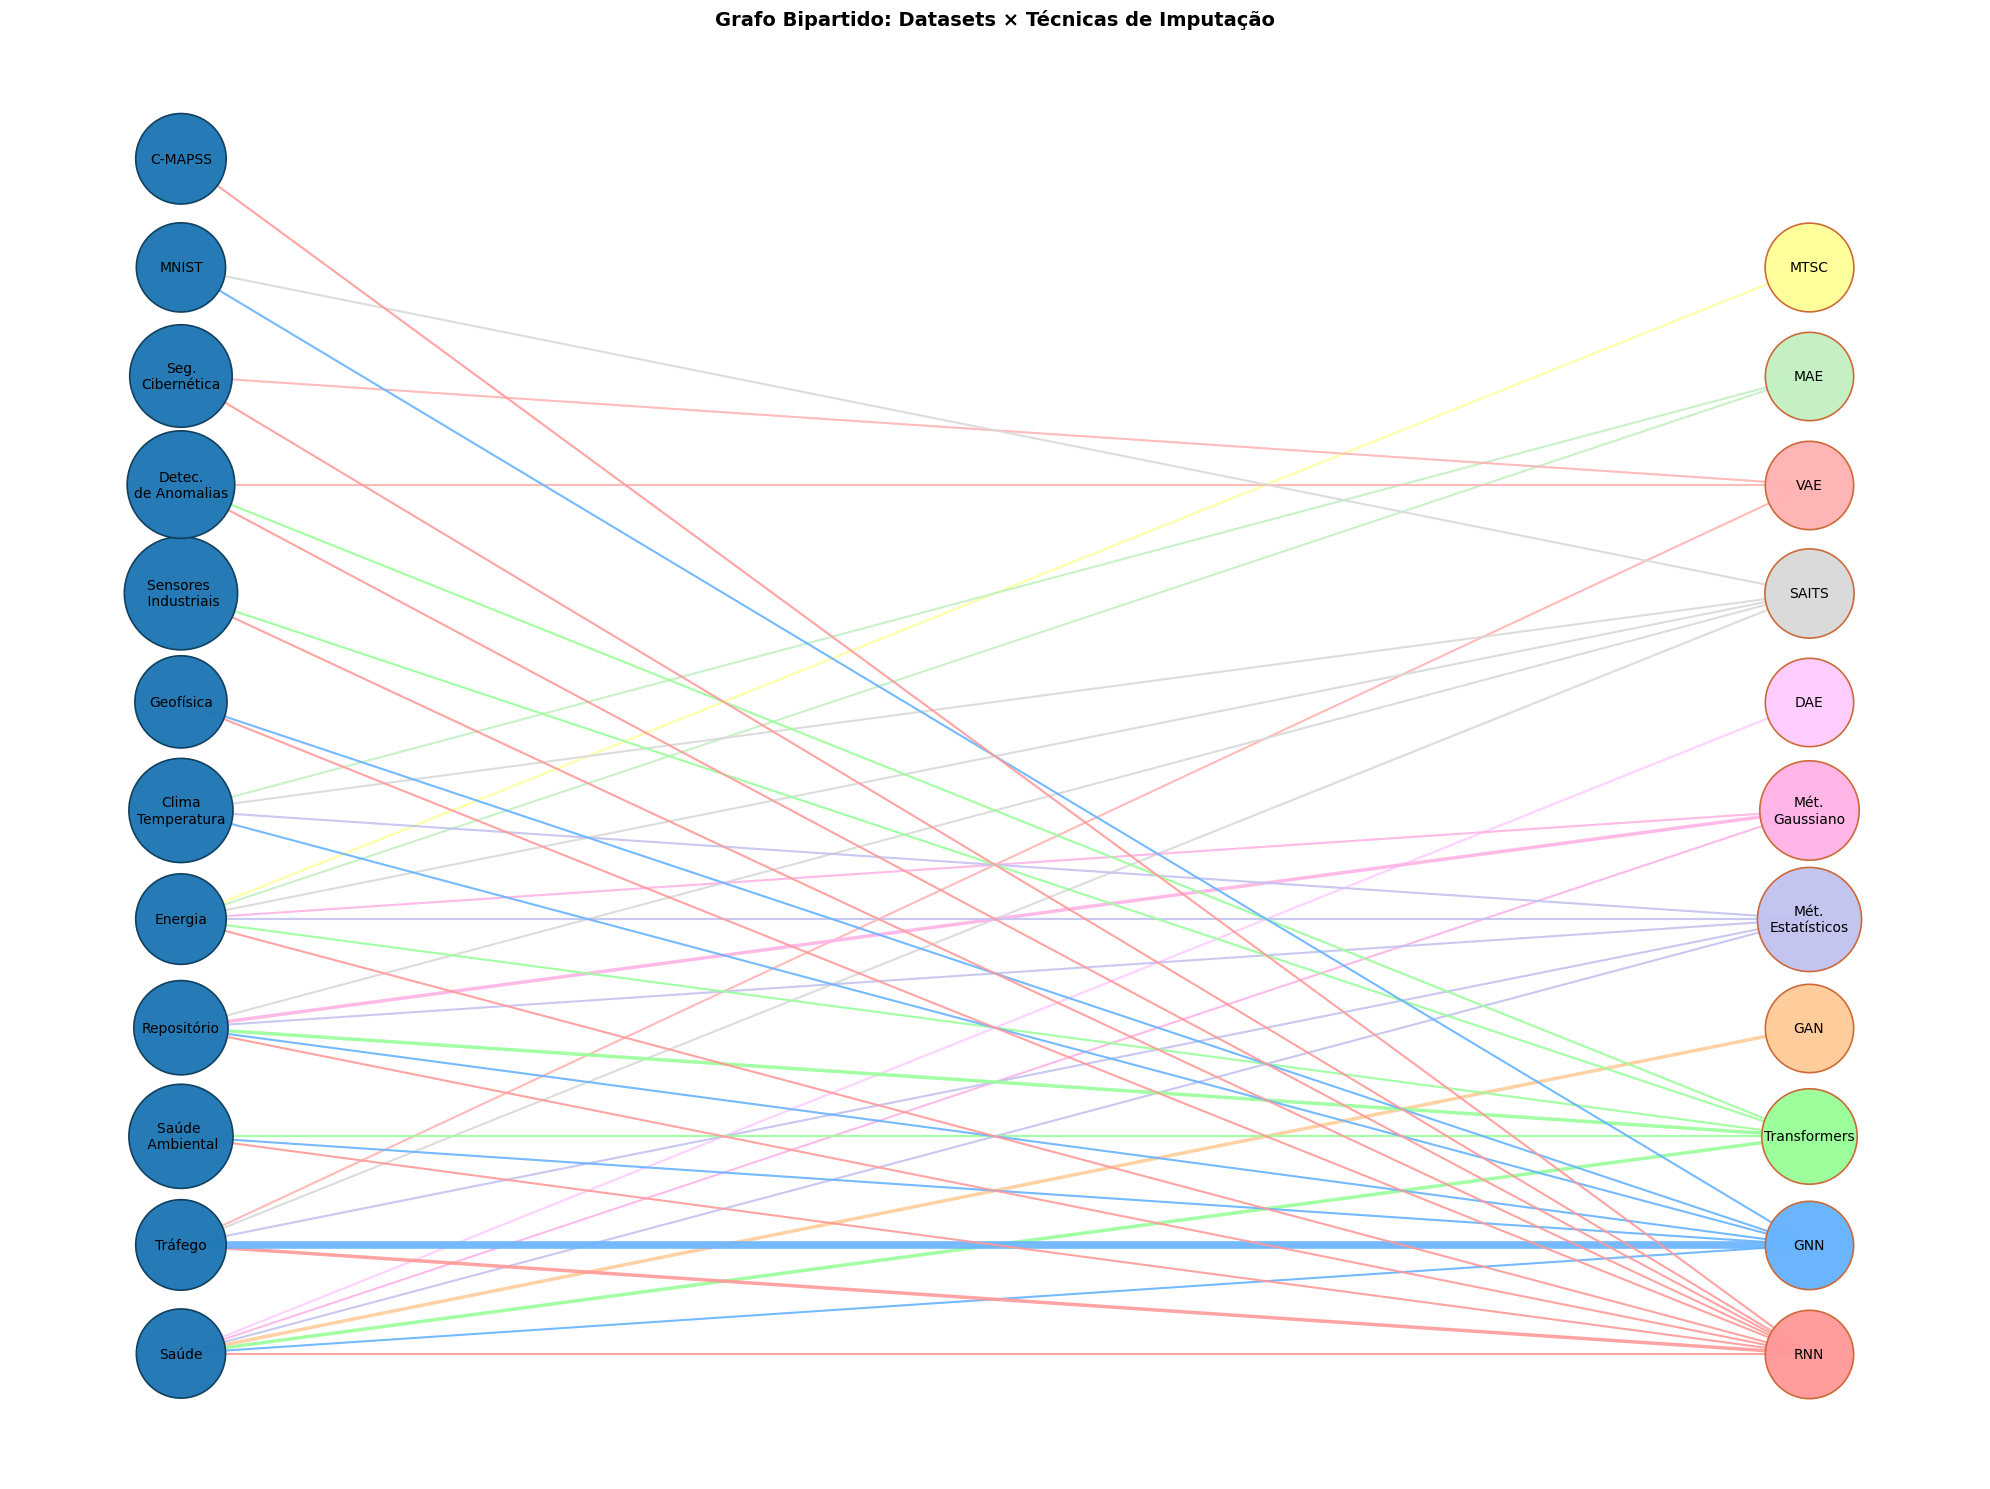

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ===== DEFINIÇÕES PARA O GRAFO DE DATASETS E TÉCNICAS DE IMPUTAÇÃO =====

# 1. Criar o grafo bipartido
G2 = nx.Graph()

# 2. Definir os datasets (lado esquerdo do grafo) - NOMES SIMPLIFICADOS
datasets = [
    'Saúde',
    'Tráfego',
    'Saúde \\n Ambiental',
    'Repositório',
    'Energia',
    'Clima\\nTemperatura',
    'Geofísica',
    'Sensores \\n Industriais',
    'Detec.\\nde Anomalias',
    'Seg.\\nCibernética',
    'MNIST',
    'C-MAPSS'
]

# 3. Definir as técnicas de imputação (lado direito do grafo)
tecnicas = [
    'RNN',
    'GNN',
    'Transformers',
    'GAN',
    'Mét.\\nEstatísticos',
    'Mét.\\nGaussiano',
    'DAE',
    'SAITS',
    'VAE',
    'MAE',
    'MTSC'
]

# 4. Adicionar os nós ao grafo
G2.add_nodes_from(datasets, bipartite=0)
G2.add_nodes_from(tecnicas, bipartite=1)

# 5. Adicionar arestas com pesos (conexões entre datasets e técnicas)
conexoes = [
    # Saúde
    ('Saúde', 'RNN', 1),
    ('Saúde', 'GNN', 1),
    ('Saúde', 'Transformers', 2),
    ('Saúde', 'GAN', 2),
    ('Saúde', 'Mét.\\nEstatísticos', 1),
    ('Saúde', 'Mét.\\nGaussiano', 1),
    ('Saúde', 'DAE', 1),
    
    # Tráfego
    ('Tráfego', 'RNN', 2),
    ('Tráfego', 'GNN', 5),
    ('Tráfego', 'SAITS', 1),
    ('Tráfego', 'Mét.\\nEstatísticos', 1),
    ('Tráfego', 'VAE', 1),
    
    # Saúde Ambiental
    ('Saúde \\n Ambiental', 'RNN', 1),
    ('Saúde \\n Ambiental', 'GNN', 1),
    ('Saúde \\n Ambiental', 'Transformers', 1),
    
    # Repositório
    ('Repositório', 'RNN', 1),
    ('Repositório', 'GNN', 1),
    ('Repositório', 'Transformers', 2),
    ('Repositório', 'SAITS', 1),
    ('Repositório', 'Mét.\\nEstatísticos', 1),
    ('Repositório', 'Mét.\\nGaussiano', 2),
    
    # Energia
    ('Energia', 'RNN', 1),
    ('Energia', 'Transformers', 1),
    ('Energia', 'SAITS', 1),
    ('Energia', 'Mét.\\nEstatísticos', 1),
    ('Energia', 'Mét.\\nGaussiano', 1),
    ('Energia', 'MAE', 1),
    ('Energia', 'MTSC', 1),
    
    # Clima/Temperatura
    ('Clima\\nTemperatura', 'GNN', 1),
    ('Clima\\nTemperatura', 'SAITS', 1),
    ('Clima\\nTemperatura', 'Mét.\\nEstatísticos', 1),
    ('Clima\\nTemperatura', 'MAE', 1),
    
    # Geofísica
    ('Geofísica', 'RNN', 1),
    ('Geofísica', 'GNN', 1),
    
    # Sensores Industriais
    ('Sensores \\n Industriais', 'RNN', 1),
    ('Sensores \\n Industriais', 'Transformers', 1),
    
    # Detecção de Anomalias
    ('Detec.\\nde Anomalias', 'RNN', 1),
    ('Detec.\\nde Anomalias', 'Transformers', 1),
    ('Detec.\\nde Anomalias', 'VAE', 1),
    
    # Segurança Cibernética
    ('Seg.\\nCibernética', 'RNN', 1),
    ('Seg.\\nCibernética', 'VAE', 1),
    
    # MNIST
    ('MNIST', 'GNN', 1),
    ('MNIST', 'SAITS', 1),
    
    # C-MAPSS
    ('C-MAPSS', 'RNN', 1),
]

for dataset, tecnica, peso in conexoes:
    G2.add_edge(dataset, tecnica, weight=peso)

# 6. Definir a ordem dos nós
cat_order = datasets
tec_order = tecnicas

# ===== CÓDIGO DE VISUALIZAÇÃO =====

# Função para ajustar o tamanho dos nós
def adjusted_node_size(label_txt):
    base_size5 = 4000
    size_scale5 = 5  # Pequeno ajuste para controlar tamanhos
    ln = len(label_txt)
    size_val = base_size5 + size_scale5 * (ln ** 2)
    return float(size_val)

cat_sizes5 = [adjusted_node_size(n) for n in cat_order]
tec_sizes5 = [adjusted_node_size(n) for n in tec_order]

# Cores para as técnicas
cores_tecnicas = {
    'RNN': '#ff9999',
    'GNN': '#66b3ff',
    'Transformers': '#99ff99',
    'GAN': '#ffcc99',
    'Mét.\\nEstatísticos': '#c2c2f0',
    'Mét.\\nGaussiano': '#ffb3e6',
    'DAE': '#ffccff',
    'SAITS': '#d9d9d9',
    'VAE': '#ffb3b3',
    'MAE': '#c2f0c2',
    'MTSC': '#ffff99'
}

# Definindo posições
pos5 = {}
for i, n in enumerate(cat_order):
    pos5[n] = (0, i * 2)
for j, n in enumerate(tec_order):
    pos5[n] = (1, j * 2)

# Estilo das arestas com cores e espessura variáveis
edges_colors = []
edge_widths = []
for u, v, data in G2.edges(data=True):  # Inclui os dados das arestas
    weight = data['weight']  # Obtém o peso da aresta
    edge_widths.append(0.5 + 1 * weight)  # Aumenta a espessura com base no peso

    if v == 'GNN':
        edges_colors.append('#66b3ff')  # Azul para GNN
    elif v == 'MTSC':
        edges_colors.append('#ffff99')  # Amarelo para MTSC
    elif v == 'RNN':
        edges_colors.append('#ff9999')  # Vermelho para RNN
    elif v == 'Transformers':
        edges_colors.append('#99ff99')  # Verde para Transformers
    elif v == 'GAN':
        edges_colors.append('#ffcc99')  # Laranja para GAN
    elif v == 'Mét.\\nEstatísticos':
        edges_colors.append('#c2c2f0')  # Roxo claro para Mét. Estatísticos
    elif v == 'Mét.\\nGaussiano':
        edges_colors.append('#ffb3e6')  # Rosa claro para Método Gaussiano
    elif v == 'DAE':
        edges_colors.append('#ffccff')  # Lilás para DAE
    elif v == 'SAITS':
        edges_colors.append('#d9d9d9')  # Cinza para SAITS
    elif v == 'VAE':
        edges_colors.append('#ffb3b3')  # Vermelho suave para VAE
    elif v == 'MAE':
        edges_colors.append('#c2f0c2')  # Verde suave para MAE

# Criar a visualização
plt.figure(figsize=(20, 15))

# Datasets em azul
nx.draw_networkx_nodes(G2, pos5, nodelist=cat_order, 
                       node_color='#1f77b4', 
                       node_size=cat_sizes5, 
                       alpha=0.97, 
                       linewidths=1.2, 
                       edgecolors='#0d3d5c')

# Técnicas
for técnica in tec_order:
    nx.draw_networkx_nodes(G2, pos5, nodelist=[técnica], 
                           node_color=cores_tecnicas[técnica], 
                           node_size=tec_sizes5[tec_order.index(técnica)], 
                           alpha=0.97, 
                           linewidths=1.2, 
                           edgecolors='#cc6633')

# Linhas com cores e espessuras baseadas em peso
nx.draw_networkx_edges(G2, pos5, 
                       width=edge_widths,  # Espessura baseada em peso
                       edge_color=edges_colors,  # Cores variáveis para cada aresta
                       alpha=0.90,  # Aumentando a opacidade
                       connectionstyle='arc3,rad=0.15')

# Ajustando as labels com quebras de linha
wrapped_labels = {}
for n in G2.nodes():
    wrapped_labels[n] = n.replace('\\n', '\n')

nx.draw_networkx_labels(G2, pos5, labels=wrapped_labels, font_size=10, font_color='black')

plt.title('Grafo Bipartido: Datasets × Técnicas de Imputação', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir o estilo
sns.set_style("whitegrid")  # Define o estilo seaborn-whitegrid